# Lab 3 Research Agent: from your question to a cited briefing

Lab 1 searched documents once. Lab 2 ran a fixed pipeline. Here the model **decides what to search for, which papers to read, whether it has learned enough, and when to stop**. That is the pattern behind every "deep research" product, and you will build it in six small functions over **arXiv itself**: 2.5 million papers, searched live through its API, any topic, any field, up to yesterday.

```
your question ─▶ 1 plan searches (model) ─▶ 2 find candidate papers (arXiv API) ─▶ 3 select the ones worth reading (model)
              ─▶ 4 download each one, read it, summarise how it works (model) ─▶ 5 assess coverage: enough? (model) ──no──▶ back to 2
                                                                                                           └──yes──▶ 6 write the briefing, verify citations
```

Finding is cheap: a search returns titles and abstracts in a second. Reading is expensive: a PDF must be downloaded and extracted. So the agent finds widely, reads narrowly, and only ever reads what it chose.

### Setup: Runtime → Change runtime type → **T4 GPU**, then run this cell

In [1]:
!pip install -q -U transformers accelerate chromadb sentence-transformers pypdf arxiv

import torch, json, re
from transformers import AutoTokenizer, AutoModelForImageTextToText

MODEL_ID = "Qwen/Qwen3.5-4B"          # 4B open model, ~9 GB in fp16, fits a free T4. (Fallback: "Qwen/Qwen3-4B")
tok = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForImageTextToText.from_pretrained(MODEL_ID, dtype=torch.float16, device_map="auto")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 100.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

...

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/76.2k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

In [2]:
def chat(messages, max_new_tokens=400, temperature=0.0):
    """The one function that talks to the model: a prompt string or a list of {role, content} -> reply text."""
    if isinstance(messages, str):
        messages = [{"role": "user", "content": messages}]
    prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)
    inputs = tok(prompt, return_tensors="pt").to(model.device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=temperature > 0,
                         temperature=temperature if temperature > 0 else None)
    return tok.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

In [3]:
print(chat("Say hello in five words."))

[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `chunk_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.
[transformers] `causal_conv1d_update` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `fused_recurrent_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.


Hello there, friend. How are you?


## 1: The source: arXiv, live

The `arxiv` package wraps arXiv's public API and respects its rate limit (one request every three seconds). A search returns metadata and the abstract for each paper; the PDF is only fetched later, for papers the agent selects. Everything the agent has seen in this session is kept in one dictionary, `PAPERS`, keyed by arXiv id.

In [4]:
import arxiv, requests, io, re, pandas as pd
from pypdf import PdfReader
from IPython.display import Markdown, display

api = arxiv.Client()                                                                   # polite by default: 3 s between requests, retries
PAPERS = {}                                                                            # id -> {title, year, authors, abstract, url, pdf, text}

def step(n, title, *lines):
    '''One banner per pipeline step, so every run reads the same way.'''
    print(f"\n{'━' * 72}\n Step {n} · {title}\n{'━' * 72}")
    for line in lines:
        print(line)

def search_arxiv(query, k=5):
    '''Ask arXiv for the k papers most relevant to a query. Returns their ids; metadata + abstract go into PAPERS.'''
    ids = []
    for r in api.results(arxiv.Search(query=query, max_results=k, sort_by=arxiv.SortCriterion.Relevance)):
        pid = r.get_short_id().split("v")[0]
        PAPERS.setdefault(pid, {"id": pid, "title": r.title.replace("\n", " "), "year": r.published.year, "authors": ", ".join(a.name for a in r.authors),
                                "abstract": r.summary.replace("\n", " "), "url": f"https://arxiv.org/abs/{pid}", "pdf": r.pdf_url, "text": None})
        ids.append(pid)
    return ids

In [5]:
search = search_arxiv                                                                  # the pipeline's source; swapped later for your own documents

for pid in search("mixture of experts inference cost", k=5):
    print(f"  {pid}  {PAPERS[pid]['year']}  {PAPERS[pid]['title'][:80]}")

  2410.17954  2024  ExpertFlow: Efficient Mixture-of-Experts Inference via Predictive Expert Caching
  2402.14800  2024  Not All Experts are Equal: Efficient Expert Pruning and Skipping for Mixture-of-
  2312.04693  2023  GraphMETRO: Mitigating Complex Graph Distribution Shifts via Mixture of Aligned 
  1806.08200  2018  Mixtures of Experts Models
  2503.03213  2025  Convergence Rates for Softmax Gating Mixture of Experts


In [6]:
print(PAPERS)

{'2410.17954': {'id': '2410.17954', 'title': 'ExpertFlow: Efficient Mixture-of-Experts Inference via Predictive Expert Caching and Token Scheduling', 'year': 2024, 'authors': 'Xin He, Shunkang Zhang, Kaijie Tang, Shaohuai Shi, Yuxin Wang, Zihao Zeng, Zhenheng Tang, Xiaowen Chu, Haiyan Yin, Ivor W. Tsang, Yew Soon Ong', 'abstract': 'Sparse Mixture-of-Experts (MoE) models can outperform dense large language models at similar computation by activating only a small set of experts per token. However, stacking many expert modules introduces substantial parameter memory, which makes MoE models difficult to deploy in memory-constrained environments such as single-GPU devices. Offloading alleviates this issue by storing inactive experts in CPU memory and loading them on demand, but existing methods remain limited: static caches disregard input-dependent routing, and methods that train separate models to predict expert usage ahead of time are often inaccurate or require significant training cost

## 2: Reading a paper: download, extract, index

`fetch_text()` downloads the PDF once and extracts its text with `pypdf`; `read_index()` chunks that text and embeds it into a **reading index** for just the selected papers; `passages()` pulls the few chunks of one paper closest to the topic. Extraction from PDFs is imperfect (two columns, equations, footers) — this is real-world text now, not a curated dataset.

In [7]:
import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

embedder = SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2", device="cuda")
client = chromadb.Client()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
def fetch_text(pid):
    '''Download the PDF (once) and extract its text.'''
    paper = PAPERS[pid]
    if paper["text"] is None:
        pdf = requests.get(paper["pdf"], timeout=90).content
        text = "\n".join(page.extract_text() or "" for page in PdfReader(io.BytesIO(pdf)).pages)
        paper["text"] = re.sub(r"[ \t]+", " ", re.sub(r"-\n(?=[a-z])", "", text))     # re-join hyphenated words, collapse spaces
    return paper["text"]

def chunk(text, size=800):
    pieces, current = [], ""
    for word in text.split():
        if len(current) + len(word) > size:
            pieces.append(current.strip()); current = ""
        current += word + " "
    return pieces + [current.strip()]

def fresh_collection(name):
    '''A new, empty collection with that name (replacing any previous one).'''
    try:
        client.delete_collection(name)
    except Exception:
        pass
    return client.create_collection(name, embedding_function=embedder, metadata={"hnsw:space": "cosine"})

def read_index(ids):
    '''The reading index: chunk and embed the full text of just these papers.'''
    reading = fresh_collection("reading")
    for pid in ids:
        pieces = chunk(fetch_text(pid))
        reading.add(ids=[f"{pid}-{i}" for i in range(len(pieces))], documents=pieces, metadatas=[{"id": pid, "title": PAPERS[pid]["title"]}] * len(pieces))
    return reading

def passages(reading, topic, pid, k=6):
    '''The k passages of one paper most relevant to the topic.'''
    return reading.query(query_texts=[topic], n_results=k, where={"id": pid})["documents"][0]

In [9]:
pid = search("mixture of experts inference cost", k=1)[0]
reading = read_index([pid])
print(f"{PAPERS[pid]['title'][:70]}: {len(PAPERS[pid]['text']):,} characters, {reading.count()} chunks")
print(passages(reading, "how are experts selected at inference time", pid, k=1)[0][:10000], "...")

ExpertFlow: Efficient Mixture-of-Experts Inference via Predictive Expe: 47,524 characters, 61 chunks
ExpertFlow: Efficient Mixture-of-Experts Inference via Predictive Expert Caching and Token Scheduling Xin He1*, Shunkang Zhang2, Kaijie Tang3, Shaohuai Shi3, Yuxin Wang4, Zihao Zeng5, Zhenheng Tang2, Xiaowen Chu6, Haiyan Yin1, Ivor W. Tsang1,5, Yew Soon Ong1,5∗ 1CFAR, Agency for Science, Technology and Research (A*STAR), Singapore 2The Hong Kong University of Science and Technology, Hong Kong 3Harbin Institute of Technology, Shenzhen, China 4Hong Kong Baptist University, Hong Kong 5Nanyang Technological University, Singapore 6The Hong Kong University of Science and Technology (Guangzhou), China Abstract Sparse Mixture-of-Experts (MoE) models can outperform dense large language models at similar computation by activating only a small set of experts per token. However, stacking many expert ...


<details><summary><b>Fallback if arXiv is slow or down today</b> — set <code>USE_DATASET = True</code> and run</summary>

The <code>jamescalam/ai-arxiv2</code> dataset holds 2,673 AI papers (2016 to early 2024) with clean full text. This cell loads them into <code>PAPERS</code>, indexes their abstracts locally, and points <code>search</code> at that index. Everything after this cell works unchanged.
</details>

In [10]:
USE_DATASET = False                                                                    # <- True only if arXiv is unavailable

def build_library(ids):
    '''A local search index over title + abstract of these papers (used instead of the arXiv API).'''
    library = fresh_collection("library")
    for i in range(0, len(ids), 500):
        batch = ids[i:i + 500]
        library.add(ids=batch, documents=[PAPERS[p]["title"] + ". " + PAPERS[p]["abstract"] for p in batch], metadatas=[{"title": PAPERS[p]["title"]} for p in batch])
    print(library.count(), "documents in the local library index")
    return library

def search_library(query, k=8):
    return library.query(query_texts=[query], n_results=min(k, library.count()))["ids"][0]

if USE_DATASET:
    from datasets import load_dataset
    for r in load_dataset("jamescalam/ai-arxiv2", split="train"):
        text = r["content"].encode("latin-1", "ignore").decode("utf-8", "ignore")
        PAPERS[r["id"]] = {"id": r["id"], "title": r["title"], "year": int(r["published"][:4]), "authors": r["authors"], "abstract": r["summary"].replace("\n", " "),
                           "url": f"https://arxiv.org/abs/{r['id']}", "pdf": None, "text": text[text.find("\n# "):] if "\n# " in text[:3000] else text}
    library = build_library(list(PAPERS))
    search = search_library

## 3: What do you want to know?

Type a question or a topic, in any field arXiv covers (physics, biology, economics, computer science...). Press Enter for the example.

In [11]:
TOPIC = "Small Language models against large language models"

## Step 1: Plan the searches — the model's first decision

A topic is not a search query. The model breaks it into three or four different searches that together cover it. This is where the agent decides *what to look for*.

In [12]:
def chat_json(messages, **kw):
    """Same as chat(), but returns the first JSON object found in the reply as a dict."""
    text = chat(messages, **kw)
    match = re.search(r"\{.*\}", text, re.S)
    return json.loads(match.group()) if match else {}

In [13]:
def plan(topic):
    reply = chat_json(f"You research a topic in the arXiv paper archive, which matches keywords, not sentences. Write 3-4 different "
                      f"keyword searches of 2-5 technical terms each (no question words, no 'large language models' on its own) that "
                      f'together cover the topic. Return JSON: {{"queries": [...]}} where every query is a plain string.\n\nTopic: {topic}')
    return [" ".join(map(str, q.values())) if isinstance(q, dict) else str(q) for q in reply.get("queries", [topic])]   # small models sometimes return objects

queries = plan(TOPIC)
step(1, "Plan searches (model)", *queries)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 1 · Plan searches (model)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
small language models efficiency large language models performance
parameter efficient fine-tuning small models versus large models
distillation techniques small language models large language models
quantization methods small language models large language models inference


## Step 2: Find candidate papers

Each query goes to the source and the hits are pooled. arXiv matches keywords, so its own ranking is weak for a topic; we **re-rank the pool by meaning**, embedding each title + abstract and scoring its similarity to the topic (Lab 1's trick). The ten best go forward. Cheap, fast, and deliberately generous: better to show the model ten candidates than to miss the right one.

In [14]:
def rank_by_meaning(topic, ids, keep=10):
    '''Embed each candidate's title + abstract and rank them by similarity to the topic -> {paper id: similarity}, best first.'''
    pool = fresh_collection("candidates")
    pool.add(ids=ids, documents=[PAPERS[p]["title"] + ". " + PAPERS[p]["abstract"] for p in ids])
    r = pool.query(query_texts=[topic], n_results=min(keep, len(ids)))
    return {pid: round(1 - d, 2) for pid, d in zip(r["ids"][0], r["distances"][0])}

def find_candidates(topic, queries, k=6, exclude=()):
    '''Pool the papers found by every query (de-duplicated), then re-rank the pool by meaning.'''
    pool = list(dict.fromkeys(pid for q in queries for pid in search(q, k) if pid not in exclude))
    return rank_by_meaning(topic, pool) if pool else {}

candidates = find_candidates(TOPIC, queries)
step(2, "Find candidates (re-ranked by meaning)", *[f"{score:.2f}  {pid}  {PAPERS[pid]['year']}  {PAPERS[pid]['title'][:75]}" for pid, score in candidates.items()])


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 2 · Find candidates (re-ranked by meaning)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
0.61  2405.11357  2024  Large Language Models Lack Understanding of Character Composition of Words
0.58  2403.17811  2024  Are Compressed Language Models Less Subgroup Robust?
0.56  2601.08844  2025  Emissions and Performance Trade-off Between Small and Large Language Models
0.56  2603.21389  2026  Task-Specific Efficiency Analysis: When Small Language Models Outperform La
0.51  2402.14800  2024  Not All Experts are Equal: Efficient Expert Pruning and Skipping for Mixtur
0.51  2501.05032  2025  Enhancing Human-Like Responses in Large Language Models
0.47  2602.08239  2026  Linearization Explains Fine-Tuning in Large Language Models
0.45  2110.06500  2021  Differentially Private Fine-tuning of Language Models
0.41  2503.21676  2025  How do language models learn facts? Dynamics, curricula and ha

## Step 3: Select the papers worth reading — the model's second decision

Similarity ranks by wording; the model ranks by usefulness. It reads the candidates' abstracts and picks the few that will actually answer the topic, with a reason for each. Reading is the expensive step, so this choice matters.

In [16]:
def select_papers(topic, candidates, n=4):
    '''The model picks the n most useful candidates -> [{"id", "why"}, ...]. Unknown ids are dropped.'''
    listing = "\n".join(f"{pid}: {PAPERS[pid]['title']} ({PAPERS[pid]['year']}) — {PAPERS[pid]['abstract'][:300]}" for pid in candidates)
    reply = chat_json(f"Topic: {topic}\n\nCandidate papers:\n{listing}\n\nPick the {n} papers most useful for a briefing on the topic, "
                      f'most useful first. Return JSON: {{"papers": [{{"id": "...", "why": "..."}}]}}', max_new_tokens=400)
    chosen = [p for p in reply.get("papers", []) if p.get("id") in candidates][:n]
    return chosen or [{"id": pid, "why": "highest similarity to the topic"} for pid in list(candidates)[:n]]

chosen = select_papers(TOPIC, candidates)
step(3, "Select papers (model)", *[f"{PAPERS[c['id']]['title'][:80]}\n     why: {c['why']}" for c in chosen])


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 3 · Select papers (model)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Task-Specific Efficiency Analysis: When Small Language Models Outperform Large L
     why: This paper directly addresses the core thesis of the topic by providing a comprehensive, task-specific efficiency analysis where Small Language Models (SLMs) are shown to outperform Large Language Models (LLMs) in specific scenarios. It offers concrete evidence for the 'when' and 'how' of SLMs replacing LLMs, which is the primary argument for adopting smaller models.
Emissions and Performance Trade-off Between Small and Large Language Models
     why: This paper tackles the critical environmental and economic barrier to LLM adoption: carbon footprint and energy consumption. By investigating SLMs as a sustainable alternative, it provides a strong justification for the shift toward smaller models based on emissions and per

### Something to highlight here

One of the papers the model picked is about the **tackling the critical environmental and economic**, which may not be the most relevant choice.

This happened because the query never specified which aspects we care about most.

> **Rule of thumb:** the vaguer your query → the more generic the answers you get.

## Step 4: Read each paper and summarise how it works — the model's third decision

For every selected paper: download and extract the PDF, build the reading index, pull the six passages most relevant to the topic, and write a structured summary from the abstract and those passages only. Problem, mechanism, results, relevance, limitations. One summary per paper, so nothing gets blended together yet.

In [17]:
def summarize_paper(topic, pid, passages):
    paper = PAPERS[pid]
    joined = "\n\n".join(f"- {p[:900]}" for p in passages)
    return chat(f"You are summarising one research paper for a briefing on: {topic}\n\nPaper: {paper['title']} ({paper['year']})\n"
                f"Abstract: {paper['abstract'][:1200]}\n\nRelevant passages:\n{joined}\n\n"
                f"Using only this material, write under these bold headings: **Problem**, **How it works** (3-4 sentences on the mechanism), "
                f"**Key results** (numbers if given), **Relevance to the topic**, **Limitations**. Maximum 200 words.", max_new_tokens=380)

summaries = {}                                                                          # title -> summary text
reading = read_index([c["id"] for c in chosen])                                         # downloads the PDFs: ~5-10 s each
for c in chosen:
    title = PAPERS[c["id"]]["title"]
    summaries[title] = summarize_paper(TOPIC, c["id"], passages(reading, TOPIC, c["id"]))
    step(4, f"Read & summarise (model) : {title[:60]}"); display(Markdown(summaries[title]))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 4 · Read & summarise (model) : Task-Specific Efficiency Analysis: When Small Language Model
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


**Problem**
Large Language Models (LLMs) incur substantial computational costs, making them unsuitable for resource-constrained deployments despite their high performance.

**How it works**
The study evaluates 16 language models across five diverse NLP tasks using a novel Performance-Efficiency Ratio (PER). This metric integrates accuracy, throughput, memory, and latency via geometric mean normalization to provide a unified efficiency score.

**Key results**
Small models (0.5–3B parameters) achieved superior PER scores across all evaluated tasks, demonstrating that marginal accuracy gains from larger models do not justify the increased resource overhead.

**Relevance to the topic**
This paper provides quantitative evidence supporting the deployment of Small Language Models (SLMs) in production environments where inference efficiency is prioritized over marginal accuracy improvements.

**Limitations**
The provided text does not specify the exact computational resources or hardware constraints of the test environment, nor does it detail the specific failure cases where larger models might still be preferable.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 4 · Read & summarise (model) : Emissions and Performance Trade-off Between Small and Large 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


**Problem**
Large Language Models (LLMs) face severe environmental concerns due to energy-intensive training and, more critically, inference, which accounts for up to 90% of a model's lifecycle emissions.

**How it works**
The study compares fine-tuned Small Language Models (SLMs) against LLMs across Natural Language Processing, Reasoning, and Programming tasks. It measures performance metrics like accuracy while calculating carbon emissions specifically during the inference phase to evaluate the trade-off between efficiency and capability.

**Key results**
In four out of six tasks, SLMs achieved comparable performance to LLMs with significantly lower emissions. For Natural Language Inference, fine-tuned FLAN-T5 Base (250M) and deBERTa v3 Base (184M) outperformed the largest LLM (DeepSeek-R1, 671B), reaching 88.0% and 88.39% accuracy respectively. Inference emissions for these SLMs were approximately 0.0019 g/query, drastically lower than the massive LLMs.

**Relevance to the topic**
This research directly addresses the viability of SLMs as sustainable alternatives to resource-heavy LLMs, demonstrating that smaller models can mitigate the environmental impact of AI without sacrificing task-specific performance.

**Limitations**
The analysis focuses solely on inference emissions rather than the full lifecycle, and results are limited to specific tasks and three fine-tuned SLM architectures per category.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 4 · Read & summarise (model) : Are Compressed Language Models Less Subgroup Robust?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


**Problem**
Large Language Models (LLMs) are expensive, limiting their societal adoption. Model compression creates smaller, scalable alternatives, yet their impact on subgroup robustness—specifically performance on minority groups defined by labels and attributes—is largely unknown.

**How it works**
The study evaluates 18 distinct compression methods applied to BERT models across three datasets (MultiNLI, CivilComments, SCOTUS). It compares the "worst-group accuracy" (WGA) of these compressed variants against the original BERTBase, analyzing how different compression techniques affect performance on specific minority subgroups.

**Key results**
Worst-group performance depends on the compression method, not just model size. While trends show decreasing accuracy as size shrinks in MultiNLI and SCOTUS, TinyBERT6 outperformed BERTBase in MultiNLI. Notably, in CivilComments, most compressed models improved WGA, with TinyBERT achieving higher scores than BERTBase due to regularization effects. However, models with fewer than 6 layers collapsed to 0 WGA in SCOTUS.

**Relevance to the topic**
This research directly addresses the tension between efficiency and fairness. It demonstrates that smaller models do not inherently suffer from worse subgroup robustness; in some cases, compression acts as beneficial regularization.

**Limitations**
The analysis is restricted to BERT language models and specific compression techniques. Furthermore, subgroup robustness is entirely dependent on the dataset characteristics, as evidenced by the divergent results across MultiNLI, CivilComments, and SCOTUS.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 4 · Read & summarise (model) : Large Language Models Lack Understanding of Character Compos
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


**Problem**
Large Language Models (LLMs) excel at word, sentence, and document-level tasks but lack reliable understanding of character composition. While intuitively simpler, character-level tasks reveal fundamental gaps in how models process the minimal units of text.

**How it works**
The study analyzes contemporary LLMs by comparing their token-level performance against their ability to perform simple character manipulation tasks. It examines how models handle different character systems (e.g., English, Chinese, Japanese) and evaluates whether they can reliably execute operations that humans perform with perfection.

**Key results**
Most LLMs fail to reliably carry out simple character composition tasks, performing significantly worse than human capabilities on these elementary operations.

**Relevance to the topic**
This paper directly addresses the limitations of Small Language models (SLMs) and LLMs regarding sub-word granularity. It suggests that current scaling laws may not fully capture the necessity of character-level awareness, a critical factor for smaller models aiming for robustness across diverse languages and tokenization schemes.

**Limitations**
The research primarily focuses on character composition tasks and does not provide specific quantitative metrics or benchmark scores for these failures. Furthermore, the analysis relies on qualitative comparisons between model behaviors and human performance rather than extensive statistical data.

## Step 5: Assess coverage: enough, or search again? — the model's fourth decision

This is what a plain pipeline cannot do. The model reads its own summaries, names what the topic still lacks, and proposes new searches for those gaps, or says it has enough. Forcing named gaps and concrete queries stops it from just saying "yes, done".

In [18]:
def assess(topic, summaries, used_queries):
    joined = "\n\n".join(f"### {title}\n{text[:700]}" for title, text in summaries.items())
    return chat_json(f"Topic: {topic}\n\nPaper summaries gathered so far:\n{joined}\n\nSearch queries already used: {used_queries}\n\n"
                     f"Which aspects of the topic are still not covered by these papers? Propose at most 2 NEW keyword searches for the gaps "
                     f"(plain strings), or none if the summaries already cover the topic well.\n"
                     f'Return JSON: {{"gaps": [...], "new_queries": [...], "enough": true/false}}', max_new_tokens=300)

audit = assess(TOPIC, summaries, queries)
step(5, "Assess coverage (model)", f"gaps: {audit.get('gaps') or 'none'}", f"enough: {audit.get('enough')}", f"new queries: {audit.get('new_queries') or 'none'}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 5 · Assess coverage (model)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
gaps: ['Practical deployment strategies for SLMs in edge devices (IoT, mobile) vs. cloud LLMs', 'Emerging architectures specifically designed for SLMs (e.g., Mamba, MoE variants) beyond standard compression', 'Evaluation of SLMs on long-context reasoning and memory compared to LLMs', 'Cost-benefit analysis of SLMs in multi-agent systems or complex workflow orchestration']
enough: False
new queries: ['small language models edge deployment mobile IoT latency cost', 'Mamba architecture small language models long context reasoning']


## Step 6: Write the briefing and verify the citations

The briefing is written from the summaries, not from raw chunks, so the prompt stays small and each paper is represented fairly. Code checks which of the papers actually read the briefing cites, flags anything cited that was never read, and appends the reference list with real arXiv links.

In [19]:
def write_briefing(topic, summaries):
    joined = "\n\n".join(f"### {title}\n{text}" for title, text in summaries.items())
    return chat(f"Write a literature briefing on: {topic}\n\nUse ONLY the paper summaries below. Structure:\n"
                f"1. **Overview** (3 sentences)\n2. **How the approaches work**: one short paragraph per paper, citing its exact title in square brackets\n"
                f"3. **Comparison**: a markdown table with columns Paper | Approach | Trade-off\n4. **What is still open** (2-3 bullets)\n"
                f"Maximum 450 words.\n\n{joined}", max_new_tokens=900)

def verify(briefing, summaries, refs):
    '''Which of the papers actually read does the briefing cite, and does it cite anything else?'''
    cited = [title for title in summaries if title.lower() in briefing.lower()]
    unknown = [c for c in re.findall(r"\[([^\]]+)\]", briefing) if c not in summaries]
    references = "\n".join(f"- {title} — {refs[title]}" for title in summaries)
    return f"cites {len(cited)} of the {len(summaries)} papers read, {len(unknown)} unknown citation{'s' if len(unknown) != 1 else ''}{': ' + str(unknown) if unknown else ''}", briefing + "\n\n**References**\n" + references

refs = {PAPERS[c["id"]]["title"]: PAPERS[c["id"]]["url"] for c in chosen}
check, final = verify(write_briefing(TOPIC, summaries), summaries, refs)
step(6, "Briefing (model) + citation check", check); display(Markdown(final))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 6 · Briefing (model) + citation check
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
cites 4 of the 4 papers read, 0 unknown citations


### Literature Briefing: Small Language Models vs. Large Language Models

**Overview**
Recent research highlights a paradigm shift where Small Language Models (SLMs) increasingly outperform Large Language Models (LLMs) in specific efficiency, sustainability, and robustness metrics. While LLMs traditionally dominate general capability, SLMs offer superior performance-to-resource ratios, significantly lower carbon footprints, and potential advantages in subgroup fairness. However, challenges remain regarding character-level understanding and the consistency of compression effects across diverse datasets.

**How the approaches work**
The first study introduces a novel Performance-Efficiency Ratio (PER) metric that integrates accuracy, throughput, memory, and latency to evaluate 16 models across five NLP tasks. By normalizing these diverse factors via geometric mean, the approach quantifies efficiency, revealing that small models (0.5–3B parameters) achieve superior scores because marginal accuracy gains from larger models do not justify their increased resource overhead.

[Task-Specific Efficiency Analysis: When Small Language Models Outperform Large Language Models]

The second approach compares fine-tuned SLMs against LLMs by measuring both task accuracy and carbon emissions specifically during the inference phase. It evaluates performance across Natural Language Processing, Reasoning, and Programming tasks, demonstrating that SLMs like FLAN-T5 Base and deBERTa v3 can match or exceed the accuracy of massive models like DeepSeek-R1 while generating approximately 0.0019 g/query in emissions.

[Emissions and Performance Trade-off Between Small and Large Language Models]

The third method assesses subgroup robustness by applying 18 distinct compression techniques to BERT models across three datasets to analyze "worst-group accuracy." It determines that compression impacts fairness differently depending on the technique and dataset; while some models saw performance collapse on minority groups, others like TinyBERT improved scores due to regularization effects, proving that smaller models do not inherently suffer from worse subgroup robustness.

[Are Compressed Language Models Less Subgroup Robust?]

The final study analyzes LLMs by comparing their token-level performance against their ability to execute simple character manipulation tasks across English, Chinese, and Japanese. It reveals a fundamental gap where most LLMs fail to reliably perform elementary character composition operations, suggesting that current scaling laws may overlook the necessity of character-level awareness for robustness in diverse tokenization schemes.

[Large Language Models Lack Understanding of Character Composition of Words]

**Comparison**

| Paper | Approach | Trade-off |
| :--- | :--- | :--- |
| Task-Specific Efficiency Analysis... | Performance-Efficiency Ratio (PER) | Superior efficiency scores for SLMs vs. marginal accuracy gains for LLMs. |
| Emissions and Performance Trade-off... | Inference carbon measurement | Comparable accuracy for SLMs with drastically lower emissions than LLMs. |
| Are Compressed Language Models Less Subgroup Robust? | Worst-group accuracy analysis | Compression effects vary by method; some SLMs improve fairness, others collapse. |
| Large Language Models Lack Understanding... | Character composition benchmark | LLMs fail elementary character tasks, highlighting a gap in sub-word granularity. |

**What is still open**
*   The specific hardware constraints and failure cases where larger models remain preferable despite lower efficiency scores are not fully detailed.
*   Results regarding subgroup robustness and character composition are heavily dependent on specific dataset characteristics and model architectures.
*   Comprehensive lifecycle emissions analysis is currently limited to inference phases only.

**References**
- Task-Specific Efficiency Analysis: When Small Language Models Outperform Large Language Models — https://arxiv.org/abs/2603.21389
- Emissions and Performance Trade-off Between Small and Large Language Models — https://arxiv.org/abs/2601.08844
- Are Compressed Language Models Less Subgroup Robust? — https://arxiv.org/abs/2403.17811
- Large Language Models Lack Understanding of Character Composition of Words — https://arxiv.org/abs/2405.11357

## The whole agent

Steps 1 to 6 in one function, with the loop that makes it an agent: after step 5, if the model names gaps and new queries, the agent goes back to step 2 for those gaps, reads more papers, and assesses again, until it says *enough* or the round budget runs out. Budgets always beat the model's judgement.

In [19]:
def research(topic, max_rounds=2, per_round=4):
    print(f"\nTOPIC: {topic}")
    queries, used, read_ids, summaries, refs = plan(topic), [], set(), {}, {}
    step(1, "Plan searches (model)", *queries)
    for round_no in range(1, max_rounds + 1):
        candidates = find_candidates(topic, queries, exclude=read_ids)                 # 2 · never re-read a paper
        used += queries;   step(2, f"Find candidates · round {round_no}", *[f"{score:.2f}  {PAPERS[pid]['year']}  {PAPERS[pid]['title'][:75]}" for pid, score in candidates.items()])
        if not candidates:
            step(6, "Briefing", "No papers found for these searches - rephrase the topic."); return summaries
        chosen = select_papers(topic, candidates, n=per_round if round_no == 1 else 2)  # 3
        step(3, "Select papers (model)", *[f"{PAPERS[c['id']]['title'][:80]}\n     why: {c['why']}" for c in chosen])
        reading = read_index([c["id"] for c in chosen])                                # 4 · download + extract + index
        for c in chosen:
            title = PAPERS[c["id"]]["title"]
            summaries[title] = summarize_paper(topic, c["id"], passages(reading, topic, c["id"]))
            refs[title] = PAPERS[c["id"]]["url"]; read_ids.add(c["id"])
            step(4, f"Read & summarise (model) · {title[:60]}"); display(Markdown(summaries[title]))
        audit = assess(topic, summaries, used)                                         # 5
        step(5, "Assess coverage (model)", f"gaps: {audit.get('gaps') or 'none'}", f"enough: {audit.get('enough')}", f"new queries: {audit.get('new_queries') or 'none'}")
        if audit.get("enough") or not audit.get("new_queries"):
            break
        queries = [str(q) for q in audit["new_queries"]]
    check, final = verify(write_briefing(topic, summaries), summaries, refs)            # 6
    step(6, "Briefing (model) + citation check", f"{len(summaries)} papers read · {check}"); display(Markdown(final))
    return summaries

summaries = research(TOPIC)


TOPIC: Small Language models against large language models

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 1 · Plan searches (model)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
small language models efficiency large language models performance
parameter efficient fine-tuning small models versus large models
distillation techniques small language models large language models
quantization methods small language models large language models inference

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 2 · Find candidates · round 1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
0.61  2024  Large Language Models Lack Understanding of Character Composition of Words
0.58  2024  Are Compressed Language Models Less Subgroup Robust?
0.56  2025  Emissions and Performance Trade-off Between Small and Large Language Models
0.56  2026  Task-Specific Efficiency Analysis: When Small Langu

**Problem**
Large Language Models (LLMs) incur substantial computational costs, making them unsuitable for resource-constrained deployments despite their high performance.

**How it works**
The study evaluates 16 language models across five diverse NLP tasks using a novel Performance-Efficiency Ratio (PER). This metric integrates accuracy, throughput, memory, and latency via geometric mean normalization to provide a unified efficiency score.

**Key results**
Small models (0.5–3B parameters) achieved superior PER scores across all evaluated tasks, demonstrating that marginal accuracy gains from larger models do not justify the increased resource overhead.

**Relevance to the topic**
This paper provides quantitative evidence supporting the deployment of Small Language Models (SLMs) in production environments where inference efficiency is prioritized over marginal accuracy improvements.

**Limitations**
The provided text does not specify the exact computational resources or hardware constraints of the test environment, nor does it detail the specific failure cases where larger models might still be preferable.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 4 · Read & summarise (model) · Emissions and Performance Trade-off Between Small and Large 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


**Problem**
Large Language Models (LLMs) face severe environmental concerns due to energy-intensive training and, more critically, inference, which accounts for up to 90% of a model's lifecycle emissions.

**How it works**
The study compares fine-tuned Small Language Models (SLMs) against LLMs across Natural Language Processing, Reasoning, and Programming tasks. It measures performance metrics like accuracy while calculating carbon emissions specifically during the inference phase to evaluate the trade-off between efficiency and capability.

**Key results**
In four out of six tasks, SLMs achieved comparable performance to LLMs with significantly lower emissions. For Natural Language Inference, fine-tuned FLAN-T5 Base (250M) and deBERTa v3 Base (184M) outperformed the largest LLM (DeepSeek-R1, 671B), reaching 88.0% and 88.39% accuracy respectively. Inference emissions for these SLMs were approximately 0.0019 g/query, drastically lower than the massive LLMs.

**Relevance to the topic**
This research directly addresses the viability of SLMs as sustainable alternatives to resource-heavy LLMs, demonstrating that smaller models can mitigate the environmental impact of AI without sacrificing task-specific performance.

**Limitations**
The analysis focuses solely on inference emissions rather than the full lifecycle, and results are limited to specific tasks and three fine-tuned SLM architectures per category.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 4 · Read & summarise (model) · Are Compressed Language Models Less Subgroup Robust?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


...

**Problem**
Large Reasoning Language Models (LRLMs) suffer from "overthinking," generating excessive, redundant reasoning steps that degrade efficiency without improving accuracy. Existing methods struggle to balance high-quality reasoning with cost reduction.

**How it works**
ARS is a training-free approach that dynamically suppresses redundant steps using adaptive certainty monitoring. It employs a multi-checkpoint mechanism to estimate model confidence, adjusting suppression thresholds progressively based on reasoning patterns. Unlike static methods, it intelligently halts generation when certainty is high, preventing unnecessary token consumption.

**Key results**
On mathematical benchmarks (MATH500, GSM8K), ARS achieved up to 53% token reduction, 46.1% latency reduction, and 57.9% energy reduction while maintaining or improving accuracy compared to baselines like TALE and CGRS.

**Relevance to the topic**
This paper directly addresses the efficiency gap between Large Reasoning Models and Small Language Models (SLMs). By drastically reducing inference costs and token counts, ARS makes advanced reasoning capabilities more accessible, potentially allowing SLMs to compete with LRLMs on complex tasks without requiring massive compute resources.

**Limitations**
The study relies on specific model architectures (e.g., Qwen, DeepSeek) and benchmarks; generalizability to other domains or model types remains unverified. Additionally, the method's effectiveness depends on the model's inherent ability to generate accurate certainty signals.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 4 · Read & summarise (model) · Exploring the Limitations of Mamba in COPY and CoT Reasoning
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


**Problem**
Transformers suffer from linear inference overhead with sequence length, while Mamba offers constant size. The core question is whether Mamba can consistently match Transformer performance while maintaining these computational savings.

**How it works**
Mamba utilizes a state-space model architecture that maintains constant inference size regardless of input length, unlike Transformers where attention scales linearly. By leveraging connections to linear attention, Mamba processes sequences efficiently. However, its ability to scale with input length is constrained, requiring linear growth in model size to match Transformer capabilities for specific tasks.

**Key results**
Constant-sized Mamba struggles with COPY operations, whereas Transformers handle them easily. When Mamba size grows linearly with input length, it achieves accurate COPY performance but loses its overhead savings.

**Relevance to the topic**
This paper directly addresses the trade-off between efficiency and capability in Small Language Models (SLMs) versus Large Language Models (LLMs). It challenges the assumption that Mamba's constant size guarantees superior performance across all tasks, specifically highlighting failures in reasoning and memory tasks.

**Limitations**
Mamba cannot simultaneously achieve constant inference size and high performance on complex tasks like Chain of Thought reasoning or long-sequence copying. Its efficiency is contingent on favorable problem properties, such as locality, and fails to provide savings when scaling to match Transformer expressiveness.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 5 · Assess coverage (model)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
gaps: ['Safety and alignment risks when deploying small models in high-stakes environments', 'Multi-modal capabilities of small models compared to large models', 'Long-context handling limitations of small models versus large models', 'Domain-specific adaptation strategies for small models in specialized industries']
enough: False
new queries: ['small language models safety alignment adversarial attacks', 'small language models long context window limitations']

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 6 · Briefing (model) + citation check
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
6 papers read · cites 5 of the 6 papers read, 0 unknown citations


### Literature Briefing: Small Language Models vs. Large Language Models

**Overview**
Recent research highlights a paradigm shift where Small Language Models (SLMs) increasingly outperform Large Language Models (LLMs) in specific efficiency, environmental, and robustness metrics. While LLMs traditionally dominate in raw capability, studies demonstrate that SLMs can match or exceed performance in task-specific scenarios while drastically reducing computational costs, carbon emissions, and inference latency. However, the transition to smaller models introduces nuanced challenges regarding subgroup fairness, character-level understanding, and the trade-offs inherent in alternative architectures like Mamba.

**How the approaches work**
The first study introduces a novel Performance-Efficiency Ratio (PER) metric that integrates accuracy, throughput, memory, and latency to quantify model efficiency. By evaluating 16 models across diverse tasks, it proves that SLMs (0.5–3B parameters) achieve superior PER scores, showing that marginal accuracy gains from larger models do not justify their resource overhead.

[Emissions and Performance Trade-off Between Small and Large Language Models]
This research compares fine-tuned SLMs against LLMs by measuring both accuracy and carbon emissions specifically during the inference phase. It finds that in four out of six tasks, SLMs like FLAN-T5 Base and deBERTa v3 Base achieve comparable accuracy to massive LLMs (e.g., DeepSeek-R1) while generating approximately 0.0019 g/query, a drastically lower emission footprint.

[Are Compressed Language Models Less Subgroup Robust?]
The authors evaluate 18 compression methods applied to BERT models to assess their impact on subgroup robustness, defined as performance on minority groups. Results indicate that compression effects vary by dataset; while some models show decreased accuracy, others like TinyBERT improve worst-group accuracy through regularization, proving that smaller models do not inherently suffer from worse fairness.

[Large Language Models Lack Understanding of Character Composition of Words]
This paper analyzes LLMs' failure to perform reliable character-level manipulation tasks, revealing a fundamental gap in sub-word granularity. Unlike humans, most LLMs struggle with elementary character composition across different scripts, suggesting that scaling laws may overlook the necessity of character-level awareness for robustness in diverse tokenization schemes.

[ARS: Adaptive Reasoning Suppression for Efficient Large Reasoning Language Models]
ARS employs a training-free approach using adaptive certainty monitoring to dynamically suppress redundant reasoning steps in Large Reasoning Language Models. By halting generation when confidence is high, it achieves up to 53% token reduction and 57.9% energy reduction without sacrificing accuracy, making advanced reasoning more accessible.

[Exploring the Limitations of Mamba in COPY and CoT Reasoning]
This study investigates Mamba, a state-space model designed for constant inference size, against Transformers which scale linearly with sequence length. While Mamba offers computational savings, it struggles with tasks requiring long-term memory or complex reasoning, such as the COPY operation, unless its size grows linearly to match Transformer capabilities, thereby losing its efficiency advantage.

**Comparison**

| Paper | Approach | Trade-off |
| :--- | :--- | :--- |
| Task-Specific Efficiency Analysis | Performance-Efficiency Ratio (PER) | SLMs offer superior efficiency scores; marginal accuracy gains from LLMs are unjustified. |
| Emissions and Performance Trade-off | Inference emission measurement | SLMs match LLM accuracy in 4/6 tasks with drastically lower carbon emissions. |
| Are Compressed Language Models Less Subgroup Robust? | Compression method evaluation | Compression can improve subgroup fairness (regularization) but fails on specific datasets. |
| Large Language Models Lack Understanding of Character Composition of Words | Character-level task analysis | LLMs fail elementary character tasks; SLMs may need explicit character awareness. |
| ARS: Adaptive Reasoning Suppression | Dynamic step suppression | Reduces token/energy costs by 50%+ while maintaining accuracy in reasoning. |
| Exploring the Limitations of Mamba | State-space vs. Transformer | Constant size Mamba fails on complex reasoning/memory; efficiency lost if scaled to match Transformers. |

**What is still open**
*   The generalizability of efficiency gains and subgroup robustness across diverse model architectures and domains remains unverified beyond specific benchmarks.

**References**
- Task-Specific Efficiency Analysis: When Small Language Models Outperform Large Language Models — https://arxiv.org/abs/2603.21389
- Emissions and Performance Trade-off Between Small and Large Language Models — https://arxiv.org/abs/2601.08844
- Are Compressed Language Models Less Subgroup Robust? — https://arxiv.org/abs/2403.17811
- Large Language Models Lack Understanding of Character Composition of Words — https://arxiv.org/abs/2405.11357
- ARS: Adaptive Reasoning Suppression for Efficient Large Reasoning Language Models — https://arxiv.org/abs/2510.00071
- Exploring the Limitations of Mamba in COPY and CoT Reasoning — https://arxiv.org/abs/2410.03810

**What made it agentic.** The model chose the searches, chose the papers, judged its own coverage and decided whether to go round again; the code only fixed the order of steps, the budgets (`max_rounds`, `per_round`) and the checks (real ids only, real citations only, references from code). Compare with Lab 2, where the model never decided *whether* to take another step.

## The same agent as a graph — LangGraph

`research()` is a loop with a budget and one decision inside it. Written as a graph, the loop becomes a **cycle** with a conditional edge, the budget becomes a routing rule, and the state after every step is something you can inspect, checkpoint or resume. The six functions do not change; the graph only decides which one runs next.

In [20]:
!pip install -q "langgraph>=0.6"

from typing import TypedDict
from langgraph.graph import StateGraph, START, END

MAX_ROUNDS = 1                                                             # one round for this demo; research() used two

class Research(TypedDict, total=False):                                    # everything research() kept in local variables
    topic: str
    queries: list
    used: list
    read_ids: list
    summaries: dict
    refs: dict
    round: int
    audit: dict
    briefing: str

def plan_node(s):
    queries = plan(s["topic"]); step(1, "Plan searches (model)", *queries)
    return {"queries": queries, "used": [], "read_ids": [], "summaries": {}, "refs": {}, "round": 0}

def read_node(s):                                                          # steps 2, 3 and 4: one round of finding and reading
    round_no = s["round"] + 1
    candidates = find_candidates(s["topic"], s["queries"], exclude=set(s["read_ids"]))
    step(2, f"Find candidates · round {round_no}", *[f"{score:.2f}  {PAPERS[pid]['year']}  {PAPERS[pid]['title'][:75]}" for pid, score in candidates.items()])
    summaries, refs, read_ids = dict(s["summaries"]), dict(s["refs"]), list(s["read_ids"])
    if candidates:
        chosen = select_papers(s["topic"], candidates, n=4 if round_no == 1 else 2)
        step(3, "Select papers (model)", *[f"{PAPERS[c['id']]['title'][:80]}\n     why: {c['why']}" for c in chosen])
        reading = read_index([c["id"] for c in chosen])
        for c in chosen:
            title = PAPERS[c["id"]]["title"]
            summaries[title] = summarize_paper(s["topic"], c["id"], passages(reading, s["topic"], c["id"]))
            refs[title] = PAPERS[c["id"]]["url"]; read_ids.append(c["id"])
            step(4, f"Read & summarise (model) · {title[:60]}"); display(Markdown(summaries[title]))
    return {"round": round_no, "summaries": summaries, "refs": refs, "read_ids": read_ids, "used": s["used"] + s["queries"]}

def assess_node(s):
    audit = assess(s["topic"], s["summaries"], s["used"]) if s["summaries"] else {"enough": True, "gaps": ["no papers found"]}
    step(5, "Assess coverage (model)", f"gaps: {audit.get('gaps') or 'none'}", f"enough: {audit.get('enough')}", f"new queries: {audit.get('new_queries') or 'none'}")
    return {"audit": audit, "queries": [str(q) for q in audit.get("new_queries") or []]}

def brief_node(s):
    check, final = verify(write_briefing(s["topic"], s["summaries"]), s["summaries"], s["refs"])
    step(6, "Briefing (model) + citation check", f"{len(s['summaries'])} papers read · {check}"); display(Markdown(final))
    return {"briefing": final}

def enough(s):                                                             # the one decision the loop was made of
    return "brief" if s["audit"].get("enough") or not s["queries"] or s["round"] >= MAX_ROUNDS else "read"

graph = StateGraph(Research)
for name, fn in [("plan", plan_node), ("read", read_node), ("assess", assess_node), ("brief", brief_node)]:
    graph.add_node(name, fn)
graph.add_edge(START, "plan")
graph.add_edge("plan", "read")
graph.add_edge("read", "assess")
graph.add_conditional_edges("assess", enough, {"read": "read", "brief": "brief"})
graph.add_edge("brief", END)
researcher = graph.compile()

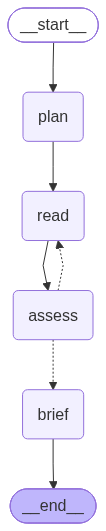

In [21]:
from IPython.display import Image
try:
    display(Image(researcher.get_graph().draw_mermaid_png()))               # the loop, drawn by the library from the edges
except Exception:
    print(researcher.get_graph().draw_mermaid())                            # the same diagram as text, if the renderer is unreachable

In [22]:
result = researcher.invoke({"topic": TOPIC})                              # same functions, same banners; papers already fetched are reused


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 1 · Plan searches (model)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
small language models efficiency large language models performance
parameter efficient fine-tuning small models versus large models
distillation techniques small language models large language models
quantization methods small language models large language models inference

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 2 · Find candidates · round 1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
0.61  2024  Large Language Models Lack Understanding of Character Composition of Words
0.58  2024  Are Compressed Language Models Less Subgroup Robust?
0.56  2025  Emissions and Performance Trade-off Between Small and Large Language Models
0.56  2026  Task-Specific Efficiency Analysis: When Small Language Models Outperform La
0.51  2024  Not All Experts are Equ

**Problem**
Large Language Models (LLMs) incur substantial computational costs, making them unsuitable for resource-constrained deployments despite their high performance.

**How it works**
The study evaluates 16 language models across five diverse NLP tasks using a novel Performance-Efficiency Ratio (PER). This metric integrates accuracy, throughput, memory, and latency via geometric mean normalization to provide a unified efficiency score.

**Key results**
Small models (0.5–3B parameters) achieved superior PER scores across all evaluated tasks, demonstrating that marginal accuracy gains from larger models do not justify the increased resource overhead.

**Relevance to the topic**
This paper provides quantitative evidence supporting the deployment of Small Language Models (SLMs) in production environments where inference efficiency is prioritized over marginal accuracy improvements.

**Limitations**
The provided text does not specify the exact computational resources or hardware constraints of the test environment, nor does it detail the specific failure cases where larger models might still be preferable.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 4 · Read & summarise (model) · Emissions and Performance Trade-off Between Small and Large 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


**Problem**
Large Language Models (LLMs) face severe environmental concerns due to energy-intensive training and, more critically, inference, which accounts for up to 90% of a model's lifecycle emissions.

**How it works**
The study compares fine-tuned Small Language Models (SLMs) against LLMs across Natural Language Processing, Reasoning, and Programming tasks. It measures performance metrics like accuracy while calculating carbon emissions specifically during the inference phase to evaluate the trade-off between efficiency and capability.

**Key results**
In four out of six tasks, SLMs achieved comparable performance to LLMs with significantly lower emissions. For Natural Language Inference, fine-tuned FLAN-T5 Base (250M) and deBERTa v3 Base (184M) outperformed the largest LLM (DeepSeek-R1, 671B), reaching 88.0% and 88.39% accuracy respectively. Inference emissions for these SLMs were approximately 0.0019 g/query, drastically lower than the massive LLMs.

**Relevance to the topic**
This research directly addresses the viability of SLMs as sustainable alternatives to resource-heavy LLMs, demonstrating that smaller models can mitigate the environmental impact of AI without sacrificing task-specific performance.

**Limitations**
The analysis focuses solely on inference emissions rather than the full lifecycle, and results are limited to specific tasks and three fine-tuned SLM architectures per category.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 4 · Read & summarise (model) · Are Compressed Language Models Less Subgroup Robust?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


**Problem**
Large Language Models (LLMs) are expensive, limiting their societal adoption. Model compression creates smaller, scalable alternatives, yet their impact on subgroup robustness—specifically performance on minority groups defined by labels and attributes—is largely unknown.

**How it works**
The study evaluates 18 distinct compression methods applied to BERT models across three datasets (MultiNLI, CivilComments, SCOTUS). It compares the "worst-group accuracy" (WGA) of these compressed variants against the original BERTBase, analyzing how different compression techniques affect performance on specific minority subgroups.

**Key results**
Worst-group performance depends on the compression method, not just model size. While trends show decreasing accuracy as size shrinks in MultiNLI and SCOTUS, TinyBERT6 outperformed BERTBase in MultiNLI. Notably, in CivilComments, most compressed models improved WGA, with TinyBERT achieving higher scores than BERTBase due to regularization effects. However, models with fewer than 6 layers collapsed to 0 WGA in SCOTUS.

**Relevance to the topic**
This research directly addresses the tension between efficiency and fairness. It demonstrates that smaller models do not inherently suffer from worse subgroup robustness; in some cases, compression acts as beneficial regularization.

**Limitations**
The analysis is restricted to BERT language models and specific compression techniques. Furthermore, subgroup robustness is entirely dependent on the dataset characteristics, as evidenced by the divergent results across MultiNLI, CivilComments, and SCOTUS.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 4 · Read & summarise (model) · Large Language Models Lack Understanding of Character Compos
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


**Problem**
Large Language Models (LLMs) excel at word, sentence, and document-level tasks but lack reliable understanding of character composition. While intuitively simpler, character-level tasks reveal fundamental gaps in how models process the minimal units of text.

**How it works**
The study analyzes contemporary LLMs by comparing their token-level performance against their ability to perform simple character manipulation tasks. It examines how models handle different character systems (e.g., English, Chinese, Japanese) and evaluates whether they can reliably execute operations that humans perform with perfection.

**Key results**
Most LLMs fail to reliably carry out simple character composition tasks, performing significantly worse than human capabilities on these elementary operations.

**Relevance to the topic**
This paper directly addresses the limitations of Small Language models (SLMs) and LLMs regarding sub-word granularity. It suggests that current scaling laws may not fully capture the necessity of character-level awareness, a critical factor for smaller models aiming for robustness across diverse languages and tokenization schemes.

**Limitations**
The research primarily focuses on character composition tasks and does not provide specific quantitative metrics or benchmark scores for these failures. Furthermore, the analysis relies on qualitative comparisons between model behaviors and human performance rather than extensive statistical data.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 5 · Assess coverage (model)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
gaps: ['Practical deployment strategies for SLMs in edge devices (IoT, mobile) vs. cloud LLMs', 'Emerging architectures specifically designed for SLMs (e.g., Mamba, MoE variants) beyond standard compression', 'Evaluation of SLMs on long-context reasoning and memory compared to LLMs', 'Cost-benefit analysis of SLMs in multi-agent systems or complex workflow orchestration']
enough: False
new queries: ['small language models edge deployment mobile IoT latency cost', 'Mamba architecture small language models long context reasoning']

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Step 6 · Briefing (model) + citation check
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4 papers read · cites 4 of the 4 papers read, 0 unknown citations


### Literature Briefing: Small Language Models vs. Large Language Models

**Overview**
Recent research highlights a paradigm shift where Small Language Models (SLMs) increasingly outperform Large Language Models (LLMs) in specific efficiency, sustainability, and robustness metrics. While LLMs traditionally dominate general capability, SLMs offer superior performance-to-resource ratios, significantly lower carbon footprints, and potential advantages in subgroup fairness. However, challenges remain regarding character-level understanding and the consistency of compression effects across diverse datasets.

**How the approaches work**
The first study introduces a novel Performance-Efficiency Ratio (PER) metric that integrates accuracy, throughput, memory, and latency to evaluate 16 models across five NLP tasks. By normalizing these diverse factors via geometric mean, the approach quantifies efficiency, revealing that small models (0.5–3B parameters) achieve superior scores because marginal accuracy gains from larger models do not justify their increased resource overhead.

[Task-Specific Efficiency Analysis: When Small Language Models Outperform Large Language Models]

The second approach compares fine-tuned SLMs against LLMs by measuring both task accuracy and carbon emissions specifically during the inference phase. It evaluates performance across Natural Language Processing, Reasoning, and Programming tasks, demonstrating that SLMs like FLAN-T5 Base and deBERTa v3 can match or exceed the accuracy of massive models like DeepSeek-R1 while generating approximately 0.0019 g/query in emissions.

[Emissions and Performance Trade-off Between Small and Large Language Models]

The third method assesses subgroup robustness by applying 18 distinct compression techniques to BERT models across three datasets to analyze "worst-group accuracy." It determines that compression impacts fairness differently depending on the technique and dataset; while some models saw performance collapse on minority groups, others like TinyBERT improved scores due to regularization effects, proving that smaller models do not inherently suffer from worse subgroup robustness.

[Are Compressed Language Models Less Subgroup Robust?]

The final study analyzes LLMs by comparing their token-level performance against their ability to execute simple character manipulation tasks across English, Chinese, and Japanese. It reveals a fundamental gap where most LLMs fail to reliably perform elementary character composition operations, suggesting that current scaling laws may overlook the necessity of character-level awareness for robustness in diverse tokenization schemes.

[Large Language Models Lack Understanding of Character Composition of Words]

**Comparison**

| Paper | Approach | Trade-off |
| :--- | :--- | :--- |
| Task-Specific Efficiency Analysis... | Performance-Efficiency Ratio (PER) | Superior efficiency scores for SLMs vs. marginal accuracy gains for LLMs. |
| Emissions and Performance Trade-off... | Inference carbon measurement | Comparable accuracy for SLMs with drastically lower emissions than LLMs. |
| Are Compressed Language Models Less Subgroup Robust? | Worst-group accuracy analysis | Compression effects vary by method; some SLMs improve fairness, others collapse. |
| Large Language Models Lack Understanding... | Character composition benchmark | LLMs fail elementary character tasks, highlighting a gap in sub-word granularity. |

**What is still open**
*   The specific hardware constraints and failure cases where larger models remain preferable despite lower efficiency scores are not fully detailed.
*   Results regarding subgroup robustness and character composition are heavily dependent on specific dataset characteristics and model architectures.
*   Comprehensive lifecycle emissions analysis is currently limited to inference phases only.

**References**
- Task-Specific Efficiency Analysis: When Small Language Models Outperform Large Language Models — https://arxiv.org/abs/2603.21389
- Emissions and Performance Trade-off Between Small and Large Language Models — https://arxiv.org/abs/2601.08844
- Are Compressed Language Models Less Subgroup Robust? — https://arxiv.org/abs/2403.17811
- Large Language Models Lack Understanding of Character Composition of Words — https://arxiv.org/abs/2405.11357

Same six functions, same banners, same budget. What changed is that the loop is now a drawing, the state after every node can be saved and resumed, and a second person can read the control flow without reading `research()`. When the shape of an agent is a cycle with a decision in it, this is the tool built for that shape.

## 🗂️ Your turn: your own papers or reports

Upload the documents you actually work with (`.pdf .txt .md`): papers, reports, proposals, standards. They go into `PAPERS` (the first 1,200 characters stand in for the abstract), a local index over them replaces arXiv as the source, and the same `research()` runs with the same banners. Nothing leaves this Colab session.

In [23]:
from google.colab import files
from pypdf import PdfReader

def upload():
    """Open the file picker; return {filename: text} for .pdf / .txt / .md / .csv files."""
    texts = {}
    for name, blob in files.upload().items():
        if name.lower().endswith(".pdf"):
            open(name, "wb").write(blob)
            texts[name] = "\n".join(page.extract_text() or "" for page in PdfReader(name).pages)
        else:
            texts[name] = blob.decode("utf-8", errors="ignore")
    print({k: f"{len(v)} chars" for k, v in texts.items()})
    return texts

In [ ]:
mine = upload()
for name, text in mine.items():
    PAPERS[name] = {"id": name, "title": name, "year": 2026, "authors": "", "abstract": text[:1200].replace("\n", " "), "url": name, "pdf": None, "text": text}
library = build_library(list(mine))                                                    # a local index over YOUR documents ...
search = search_library                                                                # ... and it becomes the source. research() is unchanged.
summaries = research(input("What do you want to know about these documents? ").strip() or "What problem do these documents address, how do their approaches work, and how do they differ?")

In [ ]:
search = search_arxiv                                                                  # back to arXiv; another topic, 'quit' to stop
while True:
    q = input("Research topic: ").strip()
    if q.lower() in ("quit", "exit", "q", ""): break
    research(q)

#### If the briefing is thin, read the banners in order: were the step 1 searches good keyword queries for your topic? Did step 2 find papers with similarity above about 0.5 (arXiv matches keywords: rephrase the searches)? Did step 3 pick the ones you would have picked? Was the extracted text in step 4 readable? Each step has its own fix.

## Exercises & Recap
1. **Budget**: run `research(TOPIC, max_rounds=1)` and `max_rounds=3`. What changed in the briefing, and what did it cost in minutes?
2. **Recency**: sort by `arxiv.SortCriterion.SubmittedDate` in `search_arxiv` and ask for recent work only. What does relevance lose?
3. **A critic**: after step 6, ask the model to list every claim in the briefing that is not supported by a summary. Where would you put that in `research()`?
4. **Threshold**: drop candidates below 0.4 similarity in step 2 and let the agent say "arXiv has little on this" instead of reading weak papers. Where does the message belong?

| Step | Who decides | Function |
|---|---|---|
| 1 Plan searches | **model** | `plan()` |
| 2 Find candidates, re-rank by meaning | code · arXiv API (or your local index) + embeddings | `find_candidates()`, `rank_by_meaning()` |
| 3 Select papers | **model** | `select_papers()` |
| 4 Download, read and summarise | **model**, reading index | `fetch_text()`, `read_index()`, `passages()`, `summarize_paper()` |
| 5 Assess coverage, loop or stop | **model**, bounded by `max_rounds` | `assess()` |
| 6 Briefing and citation check | **model**, then code | `write_briefing()`, `verify()` |

*Papers come from [arXiv](https://arxiv.org) through its public API; each keeps its own licence. Fallback dataset: [jamescalam/ai-arxiv2](https://huggingface.co/datasets/jamescalam/ai-arxiv2).*